<a href="https://colab.research.google.com/github/A-ros1076/BUS118s/blob/Dev/Coding_Exercise_ML_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Part 1: Predict house prices based on square footage and location**


Data generated using Claude Prompt + Zillow

In [3]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Part 1: House Price Prediction using Linear Regression
# Data source: Based on Redfin, RealtyTrac, and Zillow market data for San Jose, CA (Feb 2025)
# Berryessa: median $1.38M, ~$750/sqft
# Evergreen: median $1.70M, ~$1,020/sqft
# Downtown: median $1.0M, ~$728/sqft
# East SJ: median ~$850K, ~$650/sqft
# North SJ: median ~$1.3M, ~$850/sqft
# Synthetic dataset generated to match actual San Jose market patterns

# 1.1: Create sample dataset (150 records, 5 locations)
square_footage = [
    # Berryessa (30 records)
    1650, 1820, 1450, 2100, 1890, 1720, 2250, 1580, 1940, 2050,
    1680, 1850, 2180, 1590, 1920, 1740, 2020, 1670, 1880, 2110,
    1760, 1950, 2090, 1620, 1840, 2140, 1700, 1870, 2030, 1780,

    # Evergreen (30 records)
    2150, 2450, 1980, 2680, 2320, 2190, 2780, 2100, 2520, 2610,
    2240, 2380, 2720, 2140, 2490, 2280, 2550, 2170, 2420, 2650,
    2300, 2480, 2590, 2210, 2360, 2640, 2260, 2410, 2570, 2330,

    # Downtown (30 records)
    1120, 1280, 950, 1450, 1190, 1090, 1520, 1010, 1340, 1480,
    1150, 1240, 1510, 1070, 1310, 1180, 1390, 1130, 1270, 1460,
    1200, 1290, 1420, 1100, 1250, 1490, 1140, 1320, 1440, 1220,

    # East San Jose (30 records)
    1380, 1550, 1240, 1720, 1460, 1410, 1780, 1310, 1620, 1690,
    1420, 1510, 1750, 1340, 1580, 1450, 1640, 1390, 1540, 1710,
    1480, 1560, 1670, 1360, 1490, 1730, 1430, 1570, 1660, 1500,

    # North San Jose (30 records)
    1820, 2020, 1680, 2280, 1950, 1860, 2340, 1740, 2140, 2250,
    1890, 1980, 2310, 1770, 2110, 1920, 2180, 1810, 2040, 2270,
    1940, 2070, 2220, 1790, 1990, 2300, 1850, 2100, 2240, 1970
]

location = [
    *['Berryessa'] * 30,
    *['Evergreen'] * 30,
    *['Downtown'] * 30,
    *['East SJ'] * 30,
    *['North SJ'] * 30
]

price = [
    # Berryessa - ~$750/sqft
    1187250, 1312500, 1043750, 1518750, 1372500, 1237500, 1631250, 1137500, 1405000, 1481250,
    1212500, 1337500, 1585000, 1147500, 1390000, 1255000, 1465000, 1202500, 1360000, 1532500,
    1270000, 1412500, 1516250, 1168750, 1330000, 1555000, 1225000, 1352500, 1472500, 1285000,

    # Evergreen - ~$1,020/sqft
    2088750, 2379000, 1925400, 2604600, 2254800, 2126100, 2702280, 2040600, 2448600, 2536620,
    2176800, 2312760, 2642160, 2079420, 2420580, 2215560, 2479500, 2108340, 2353260, 2575500,
    2233800, 2407680, 2516280, 2144220, 2294520, 2565360, 2195520, 2343540, 2497140, 2263260,

    # Downtown - ~$728/sqft
    795840, 908640, 674400, 1029200, 845280, 773280, 1078016, 716128, 951424, 1050304,
    816080, 880384, 1073728, 760576, 930928, 838544, 987024, 802736, 903152, 1036448,
    851040, 915264, 1009184, 780800, 887500, 1057792, 809344, 936832, 1022144, 866656,

    # East SJ - ~$650/sqft
    869700, 978750, 782600, 1087400, 921100, 890250, 1124700, 826750, 1024300, 1067150,
    896300, 954250, 1106250, 845100, 998700, 915750, 1035400, 877550, 972100, 1081150,
    934400, 988600, 1055750, 858400, 941350, 1094450, 903950, 991550, 1048900, 947500,

    # North SJ - ~$850/sqft
    1487500, 1651000, 1378000, 1869000, 1597500, 1524500, 1919500, 1426500, 1754500, 1843750,
    1547750, 1623500, 1896350, 1450250, 1733750, 1574000, 1786500, 1484250, 1673000, 1862750,
    1589500, 1693750, 1820500, 1464250, 1628750, 1887500, 1514750, 1722500, 1835000, 1613750
]

# Create DataFrame
data = {
    'square_footage': square_footage,
    'location': location,
    'price': price
}
df = pd.DataFrame(data)

# Features and target
X = df[['square_footage', 'location']]
y = df['price']

# 1.2: Preprocessing - One-hot encode the location column
preprocessor = ColumnTransformer(
    transformers=[
        ('location', OneHotEncoder(sparse_output=False), ['location'])
    ], remainder='passthrough')

# 1.3: Create pipeline with preprocessing and model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model.fit(X_train, y_train)

# 1.4: Make prediction for a new house: 2000 sq ft in Evergreen (95132)
new_house = pd.DataFrame({'square_footage': [2000], 'location': ['Evergreen']})
predicted_price = model.predict(new_house)

print(f"Dataset: {len(df)} records across 5 San Jose neighborhoods")
print(f"\nPredicted price for a 2000 sq ft house in 95132 (Evergreen): ${predicted_price[0]:,.2f}")

# 1.5: Display model coefficients
location_encoder = model.named_steps['preprocessor'].named_transformers_['location']
location_features = location_encoder.get_feature_names_out(['location']).tolist()
feature_names = location_features + ['square_footage']
coefficients = model.named_steps['regressor'].coef_

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"  {feature}: ${coef:,.2f}")

print(f"\nIntercept: ${model.named_steps['regressor'].intercept_:,.2f}")

Dataset: 150 records across 5 San Jose neighborhoods

Predicted price for a 2000 sq ft house in 95132 (Evergreen): $2,013,590.09

Model Coefficients:
  location_Berryessa: $-129,248.60
  location_Downtown: $-104,723.91
  location_East SJ: $-246,617.67
  location_Evergreen: $427,277.10
  location_North SJ: $53,313.07
  square_footage: $792.70

Intercept: $910.67


**Part 2: Predict Customer Churn**

Data generated using random module




In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Part 2: Customer Churn Prediction using Logistic Regression
# Data source: Synthetic dataset based on typical SaaS/telecom churn patterns
# 150 records across 5 regions

np.random.seed(42)
n_samples = 150

# Generate realistic customer data
age = np.random.randint(25, 55, n_samples)
monthly_usage_hours = np.random.randint(10, 65, n_samples)
purchase_amount = np.random.randint(100, 365, n_samples)
customer_service_calls = np.random.randint(0, 10, n_samples)

region = [
    *['West'] * 30,
    *['East'] * 30,
    *['North'] * 30,
    *['South'] * 30,
    *['Central'] * 30
]

# Churn logic: high service calls + low usage = higher churn probability
churn = []
for i in range(n_samples):
    churn_prob = 0.3
    if customer_service_calls[i] >= 5:
        churn_prob += 0.3
    if monthly_usage_hours[i] < 25:
        churn_prob += 0.2
    if purchase_amount[i] < 150:
        churn_prob += 0.1
    churn.append(1 if np.random.random() < churn_prob else 0)

# Create DataFrame
data = {
    'age': age.tolist(),
    'monthly_usage_hours': monthly_usage_hours.tolist(),
    'purchase_amount': purchase_amount.tolist(),
    'customer_service_calls': customer_service_calls.tolist(),
    'region': region,
    'churn': churn
}
df = pd.DataFrame(data)

# Features and target
X = df[['age', 'monthly_usage_hours', 'purchase_amount', 'customer_service_calls', 'region']]
y = df['churn']

# 2.2: Preprocessing - Scale numerical and encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'monthly_usage_hours', 'purchase_amount', 'customer_service_calls']),
        ('cat', OneHotEncoder(sparse_output=False), ['region'])
    ])

# 2.3: Create pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

# 2.4: Predict for new customer
new_customer = pd.DataFrame({
    'age': [35],
    'monthly_usage_hours': [20],
    'purchase_amount': [150],
    'customer_service_calls': [5],
    'region': ['West']
})

churn_probability = model.predict_proba(new_customer)[0][1]
threshold = 0.5
churn_prediction = 1 if churn_probability > threshold else 0

# 2.5: Display coefficients
num_features = ['age', 'monthly_usage_hours', 'purchase_amount', 'customer_service_calls']
cat_encoder = model.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(['region']).tolist()
feature_names = cat_features + num_features
coefficients = model.named_steps['classifier'].coef_[0]

print(f"Churn Probability for new customer: {churn_probability:.2f}")
print(f"Churn Prediction (1 = churn, 0 = no churn): {churn_prediction}")

print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

Churn Probability for new customer: 0.45
Churn Prediction (1 = churn, 0 = no churn): 0

Model Coefficients:
region_Central: -0.31
region_East: 0.07
region_North: -0.01
region_South: 0.70
region_West: -0.45
age: 0.46
monthly_usage_hours: 0.40
purchase_amount: -0.13
customer_service_calls: -0.30


**Part 3: Customer Segmentation**

Data generated using random module


In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import random

# Part 3: Customer Segmentation using K-Means Clustering
# Data source: Synthetic dataset based on typical e-commerce customer patterns
# 150 records across 4 regions

random.seed(42)

regions = ['North', 'South', 'East', 'West']

# Generate sample customer data
data = {
    'annual_spending': [random.randint(100, 2000) for _ in range(150)],
    'purchase_frequency': [random.randint(1, 20) for _ in range(150)],
    'age': [random.randint(18, 65) for _ in range(150)],
    'region': [random.choice(regions) for _ in range(150)]
}
df = pd.DataFrame(data)

# Preprocess data: Select numerical features and scale them
features = ['annual_spending', 'purchase_frequency', 'age']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using elbow method
inertia = []
K = range(1, 6)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.close()

# Apply K-Means with optimal K (e.g., 3 based on elbow method)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print("Cluster Characteristics:")
print(cluster_summary)

# Example of targeted strategies
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Strategy:")
    if cluster_summary.loc[cluster, 'annual_spending'] > 1000:
        print("High-spending customers: Offer exclusive promotions or loyalty rewards.")
    elif cluster_summary.loc[cluster, 'purchase_frequency'] > 10:
        print("Frequent buyers: Provide bulk discounts or subscription plans.")
    else:
        print("Low-engagement customers: Send personalized re-engagement campaigns.")

# Save cluster assignments to CSV
df.to_csv('customer_segments.csv', index=False)

Cluster Characteristics:
         annual_spending  purchase_frequency    age
cluster                                            
0                 926.38               16.46  38.77
1                1507.94                6.65  48.49
2                 588.20                5.98  33.83

Cluster 0 Strategy:
Frequent buyers: Provide bulk discounts or subscription plans.

Cluster 1 Strategy:
High-spending customers: Offer exclusive promotions or loyalty rewards.

Cluster 2 Strategy:
Low-engagement customers: Send personalized re-engagement campaigns.


**Extra Credit**


*   Data: https://www.kaggle.com/datasets/mikhail1681/walmart-sales





100%|██████████| 122k/122k [00:00<00:00, 39.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mikhail1681/walmart-sales/versions/2


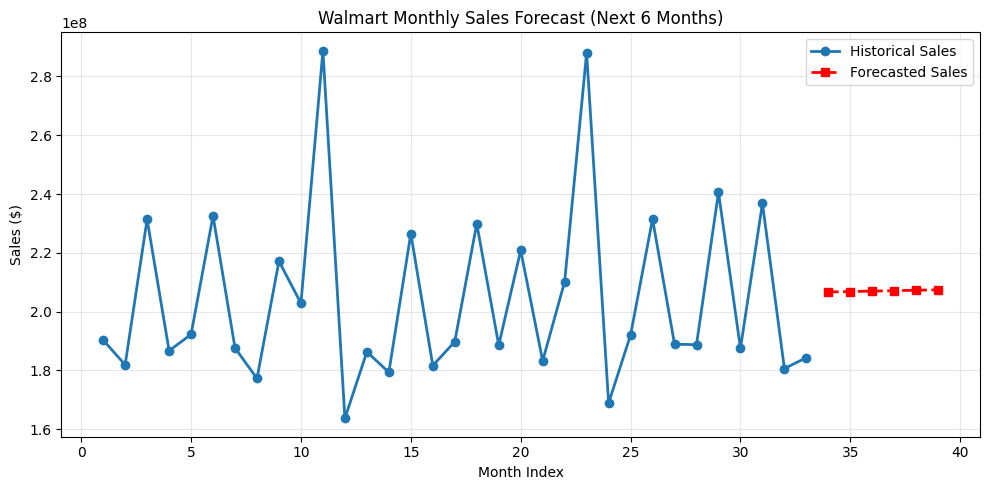


Model Performance:
  R² Score: 0.0022
  Coefficient: $148,920.05 per month
  Intercept: $201,626,510.29

6-Month Forecast:
  Month 34: $206,689,791.96
  Month 35: $206,838,712.01
  Month 36: $206,987,632.06
  Month 37: $207,136,552.10
  Month 38: $207,285,472.15
  Month 39: $207,434,392.20

--- Assumptions ---
• Linear trend assumption (sales grow/decline steadily)
• No seasonality modeling (holidays, quarters)
• Aggregated all stores (no store-specific patterns)

--- Challenges ---
• Simple linear model may miss complex patterns
• External factors (economy, competition) not considered
• Limited to 6-month horizon for reliability


In [7]:
import kagglehub
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Extra Credit: Walmart Sales Forecasting
# Data source: Walmart Sales dataset from Kaggle (mikhail1681/walmart-sales)
# Forecasting next 6 months of sales using Linear Regression

# Download dataset
path = kagglehub.dataset_download("mikhail1681/walmart-sales")
print("Path to dataset files:", path)

# Load dataset
import os
file_path = os.path.join(path, "Walmart_Sales.csv")
df = pd.read_csv(file_path)
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
df = df.set_index('Date')

# Aggregate to monthly sales
monthly_sales = df['Weekly_Sales'].resample('ME').sum().reset_index()
monthly_sales['month'] = range(1, len(monthly_sales) + 1)

# Features and target
X = monthly_sales[['month']]
y = monthly_sales['Weekly_Sales']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 6 months
future_months = pd.DataFrame({'month': range(max(X['month'])+1, max(X['month'])+7)})
predictions = model.predict(future_months)

# Visualize
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['month'], y, marker='o', label='Historical Sales', linewidth=2)
plt.plot(future_months['month'], predictions, marker='s', label='Forecasted Sales',
         linestyle='--', linewidth=2, color='red')
plt.xlabel('Month Index')
plt.ylabel('Sales ($)')
plt.title('Walmart Monthly Sales Forecast (Next 6 Months)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_forecast.png', dpi=150)
plt.show()

print(f"\nModel Performance:")
print(f"  R² Score: {model.score(X, y):.4f}")
print(f"  Coefficient: ${model.coef_[0]:,.2f} per month")
print(f"  Intercept: ${model.intercept_:,.2f}")

print(f"\n6-Month Forecast:")
for i, pred in enumerate(predictions, 1):
    print(f"  Month {future_months.iloc[i-1]['month']}: ${pred:,.2f}")

# Assumptions and challenges
print("\n--- Assumptions ---")
print("• Linear trend assumption (sales grow/decline steadily)")
print("• No seasonality modeling (holidays, quarters)")
print("• Aggregated all stores (no store-specific patterns)")

print("\n--- Challenges ---")
print("• Simple linear model may miss complex patterns")
print("• External factors (economy, competition) not considered")
print("• Limited to 6-month horizon for reliability")